In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

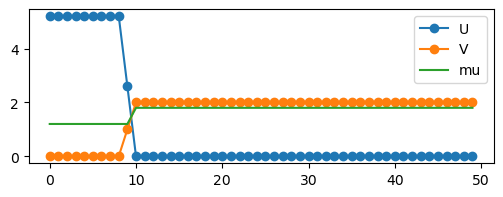

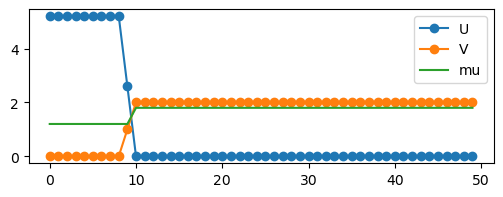

In [ ]:
widthN = 10
widthP = 40

X, Y = widthN+widthP, 100
lattice = Lattice(X, Y)
t = 1
T=0.12

muN = 1.2 * t
muP = 1.8 * t
mu = np.zeros(lattice.X)
mu[:widthN] = muN
mu[widthN:] = muP

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthN:] = 0
U[widthN-1] = U0/2

V_prime = None

V0 = 2 * t  # * 2
V = V0 * np.ones(lattice.X)
V[:widthN] = 0
V[widthN-1] = V0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()

In [3]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_t=V, g_s=V,
                F_init=[0.01, -0.01, 0.01j, -0.01j], F0_init=0.3)

d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


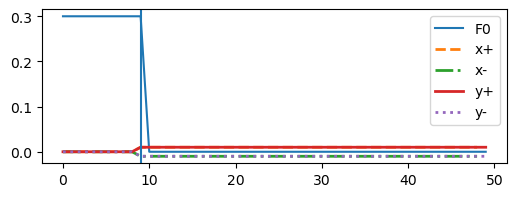

In [4]:
plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)

In [5]:
bdg_sc(H, atol=1e-6, rtol=1e-3, maxiter=500, verbose=True, temperature=T)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.1554106785689497
Relative error: 64623928325.12222
Average old: (0.06+0j)
Average: (0.06877459137406564+0j)
F_xplus:
Absolute error: 0.11215298029058691
Relative error: 101459955871.51122
Average old: (0.008163265306122448+0j)
Average: (8.145361715111719e-05+0j)
F_xmin:
Absolute error: 0.11037370852767947
Relative error: 102937221619.7443
Average old: (-0.008163265306122448+0j)
Average: (-0.015289265961426941+0j)
F_yplus:
Absolute error: 0.11904625360563031
Relative error: 110536720411.22421
Average old: 0.0082j
Average: (-0.008495881606590448+0.0076153695803706616j)
F_ymin:
Absolute error: 0.11904625360563031
Relative error: 110536720411.22421
Average old: -0.0082j
Average: (-0.008495881606590448-0.0076153695803706616j)
Fuu_xplus:
Absolute error: 2.251682587781396e-17
Relative error: 2.2516825877813958e-05
Average old: 0j
Average: (6.439030380586371e-19+0j)
Fuu_xmin:
Absolute error: 3.4914868934614654e-17
Relative error: 3.4914868934614656e-05
Average old: 0j
Ave

In [6]:
F_yplus = H.Fuu_yplus + H.Fdd_yplus 
F_ymin = H.Fuu_ymin + H.Fdd_ymin
F_xplus = np.zeros_like(F_yplus)
F_xmin = np.zeros_like(F_yplus)
F_xplus[:-1] = H.F_xplus + H.F_xplus
F_xmin[1:]  = H.F_xmin + H.F_xmin
print(F_xplus)
F0 = H.F0

F_swave2 = (F_xplus + F_xmin + F_yplus + F_ymin) / 4
F_dwave2 = (F_xplus + F_xmin - F_yplus - F_ymin) / 4
F_px2 = (F_xplus - F_xmin) / 2
F_py2 = (F_yplus - F_ymin) / 2

[-0.06547764+0.j -0.06517516+0.j -0.06463702+0.j -0.06471146+0.j
 -0.06469686+0.j -0.06468115+0.j -0.06422283+0.j -0.06416986+0.j
 -0.05447962+0.j -0.07821472+0.j -0.03872767+0.j -0.01042258+0.j
 -0.00293156+0.j  0.0040224 +0.j  0.00651185+0.j  0.00844093+0.j
  0.00912166+0.j  0.00942966+0.j  0.00935734+0.j  0.00910742+0.j
  0.00874377+0.j  0.00831605+0.j  0.00786391+0.j  0.00740121+0.j
  0.00694534+0.j  0.00650072+0.j  0.00607327+0.j  0.00566429+0.j
  0.00527477+0.j  0.00490472+0.j  0.0045534 +0.j  0.00422003+0.j
  0.00390365+0.j  0.00360276+0.j  0.00331704+0.j  0.00304399+0.j
  0.00278455+0.j  0.00253477+0.j  0.00229752+0.j  0.00206669+0.j
  0.00184796+0.j  0.00163192+0.j  0.0014286 +0.j  0.00122307+0.j
  0.00103297+0.j  0.00083275+0.j  0.00065574+0.j  0.00045229+0.j
  0.0002959 +0.j  0.        +0.j]


T=0.12t


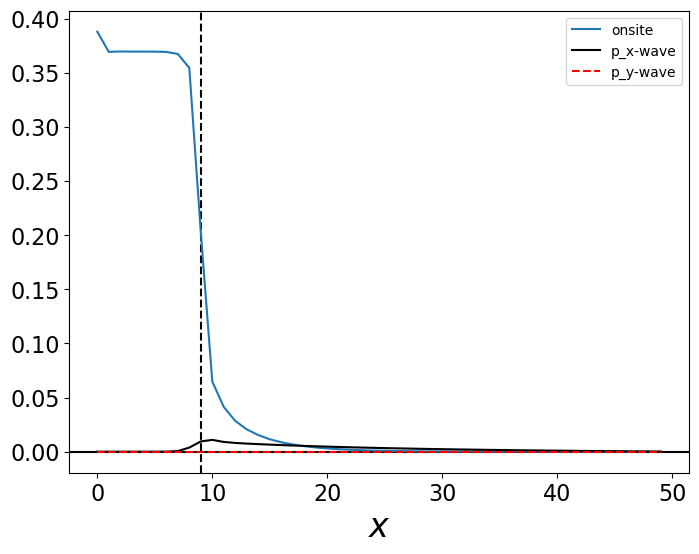

[3.87962678e-01 3.69362244e-01 3.69709071e-01 3.69606672e-01
 3.69591676e-01 3.69549129e-01 3.69320309e-01 3.67446791e-01
 3.54545252e-01 2.02635443e-01 6.47764739e-02 4.13033357e-02
 2.84097176e-02 2.06302933e-02 1.53548571e-02 1.14978780e-02
 8.74861250e-03 6.65302757e-03 5.11240459e-03 3.92731520e-03
 3.03633902e-03 2.34891419e-03 1.82414169e-03 1.41816029e-03
 1.10514692e-03 8.62229225e-04 6.73756228e-04 5.27001180e-04
 4.12705310e-04 3.23399112e-04 2.53723274e-04 1.99067455e-04
 1.56441475e-04 1.22840007e-04 9.67066378e-05 7.59851782e-05
 5.99374621e-05 4.71667045e-05 3.72727711e-05 2.94951685e-05
 2.33045695e-05 1.87817663e-05 1.47292287e-05 1.24984390e-05
 9.53636100e-06 9.17216023e-06 6.49587708e-06 8.13420261e-06
 4.59960320e-06 1.06692123e-05]


In [12]:
print(f"T={T}t")
x = np.arange(0, widthN + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.axhline(0, color = 'black')
axs.axvline(widthN-1, color='black', linestyle='--')
axs.plot(x, np.real(F0), label='onsite')
# axs.plot(x, np.real(F.swave), color='green', label="s-wave")
# axs.plot(x, np.real(F.dwave), color='blue', label="d-wave")
# axs.plot(x, np.real(Fuu.px), color='orange', label="uu:p_x-wave")
axs.plot(x, np.real(F.px), color='black', label="p_x-wave")
axs.plot(x, np.imag(F.py), "--", color='red', label="p_y-wave")

axs.set_xlabel(r"$x$", fontsize=24)
# axs.set_yticks([])
# axs.set_xlim(0, 14)
# axs.set_ylim(0, 0.3)
axs.tick_params(labelsize=16)
plt.legend()
# plt.savefig('../figures/SP.svg')
plt.show()
print(np.real(F0))

In [ ]:
T_list = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.20 + 1e-12, 0.001),
]) #
print(len(T_list))

200
